In [15]:
import numpy as np 
import matplotlib.pyplot as plt
import math

In [16]:
h = 6.62e-34
hbar = h/(2*math.pi)
q = 1.602e-19
m0 = 9.11e-31
eps0 = 8.85e-12
m_eff = 0.067 * m0
eps_r = 12.9
eps = eps_r * eps0
V0 = 0.228 * q
n_s = 2e15

In [17]:
Lw = 10e-9
Lb = 30e-9
L = 2*Lb + Lw
N = 1000
z = np.linspace(0, L, N)
dz = z[1]-z[0]

In [18]:
i_start = int(Lb / dz)
i_end   = int((Lb + Lw) / dz)
Vband   = np.full(N, V0)
Vband[i_start:i_end] = 0.0


In [19]:
def build_H(V):
    coeff = hbar**2 / (2 * m_eff * dz**2)
    main  = 2*coeff + V
    off   = -coeff * np.ones(N-1)
    return np.diag(main) + np.diag(off, 1) + np.diag(off, -1)

In [20]:
def solve_schrodinger(V):
    E_vals, psi = np.linalg.eigh(build_H(V))
    for n in range(psi.shape[1]):
        norm = np.sqrt(np.sum(psi[:,n]**2) * dz)
        psi[:,n] /= norm
    bound = E_vals < V0
    return E_vals[bound], psi[:, bound]


In [21]:
def solve_poisson(rho):
    # Poisson equation: ∇²φ = -ρ/ε
    main = -2 * np.ones(N) / dz**2
    off  =  np.ones(N-1)  / dz**2
    A    = np.diag(main) + np.diag(off, 1) + np.diag(off, -1)
    b    = -rho / eps
    A[0,:]  = 0; A[0,0]   = 1; b[0]  = 0
    A[-1,:] = 0; A[-1,-1] = 1; b[-1] = 0
    return np.linalg.solve(A, b)

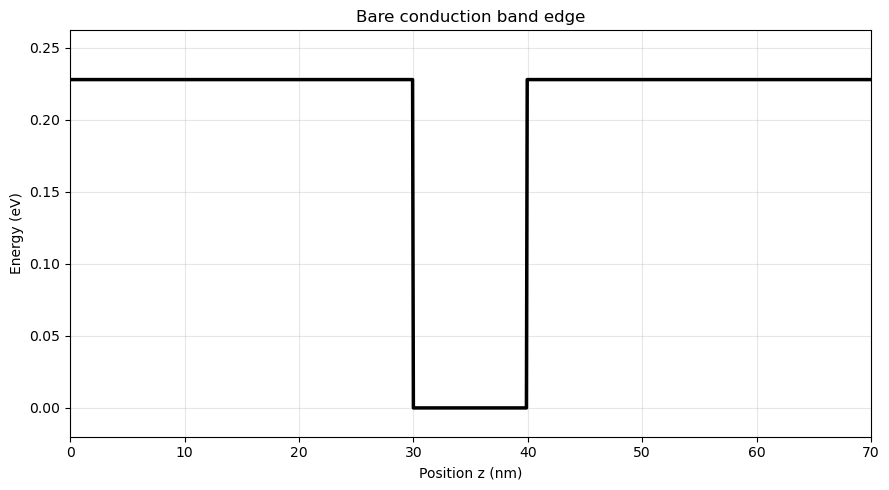

Plot 0 displayed.



In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(z*1e9, Vband/q, color='black', lw=2.5)
ax.set_xlabel('Position z (nm)')
ax.set_ylabel('Energy (eV)')
ax.set_title('Bare conduction band edge')
ax.set_xlim(0, L*1e9)
ax.set_ylim(-0.02, V0/q * 1.15)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

  n  Numerical (eV)   Analytical (eV)    % error
  1         0.05580           0.05580     0.0040
  2         0.22316           0.22320     0.0161
  3         0.50202           0.50220     0.0362
  4         0.89222           0.89280     0.0643


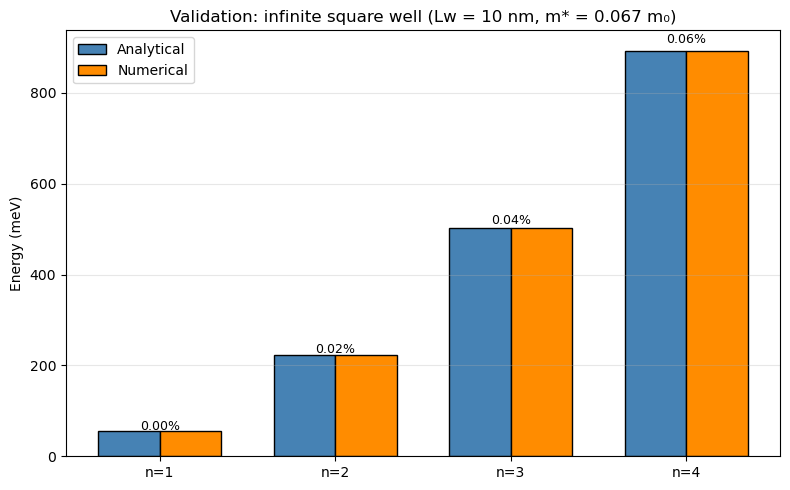

Plot 1 displayed.



In [ ]:
N_well  = i_end - i_start
coeff_w = hbar**2 / (2 * m_eff * dz**2)
main_w  = 2 * coeff_w * np.ones(N_well)
off_w   = -coeff_w * np.ones(N_well - 1)
H_inf   = np.diag(main_w) + np.diag(off_w, 1) + np.diag(off_w, -1)
E_num_all, psi_inf_all = np.linalg.eigh(H_inf)
E_num    = E_num_all[:4]
psi_inf  = psi_inf_all[:, :4]

# Normalize the infinite-well wavefunctions
for n in range(psi_inf.shape[1]):
    norm = np.sqrt(np.sum(psi_inf[:, n]**2) * dz)
    psi_inf[:, n] /= norm

# Analytical infinite well: E_n = n^2 pi^2 hbar^2 / (2 m* L_eff^2)
# Effective width = (N_well + 1)*dz because psi=0 at the implicit nodes
# just outside the matrix means the wavefunction vanishes at z=0 and z=L_eff.
L_eff = (N_well + 1) * dz
n_levels = np.arange(1, 5)
E_analytic = (n_levels**2 * np.pi**2 * hbar**2) / (2 * m_eff * L_eff**2)

# Print comparison table
print(f"{'n':>3} {'Numerical (eV)':>15} {'Analytical (eV)':>17} {'% error':>10}")
for i in range(4):
    err = 100 * abs(E_num[i] - E_analytic[i]) / E_analytic[i]
    print(f"{i+1:>3} {E_num[i]/q:>15.5f} {E_analytic[i]/q:>17.5f} {err:>10.4f}")

# Plot 1: bar chart comparison
fig, ax = plt.subplots(figsize=(8, 5))
x_pos = np.arange(4)
width = 0.35
ax.bar(x_pos - width/2, E_analytic/q*1000, width, label='Analytical',
       color='steelblue', edgecolor='black')
ax.bar(x_pos + width/2, E_num/q*1000, width, label='Numerical',
       color='darkorange', edgecolor='black')
ax.set_xticks(x_pos)
ax.set_xticklabels([f'n={n}' for n in n_levels])
ax.set_ylabel('Energy (meV)')
ax.set_title(f'Validation: infinite square well (Lw = {Lw*1e9:.0f} nm, m* = 0.067 m₀)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Add % error labels above bars
for i in range(4):
    err = 100 * abs(E_num[i] - E_analytic[i]) / E_analytic[i]
    ax.text(i, max(E_num[i], E_analytic[i])/q*1000 * 1.02,
            f'{err:.2f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

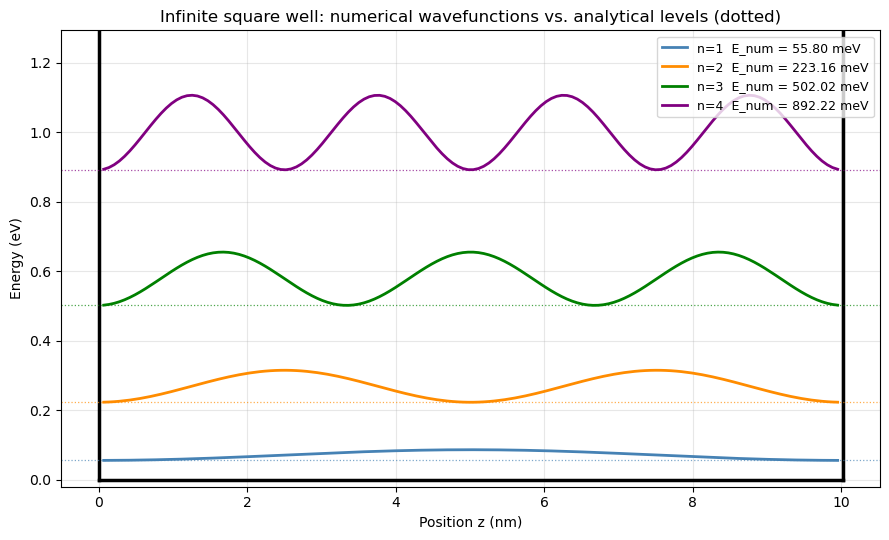

Plot 1b displayed.



In [ ]:
z_well = np.linspace(dz, N_well * dz, N_well)

fig, ax = plt.subplots(figsize=(9, 5.5))

# Draw the infinite-well "potential": V=0 inside, vertical walls at edges
wall_height = E_num[3] / q * 1.45
ax.plot([0, 0],                 [0, wall_height], color='black', lw=2.5)
ax.plot([L_eff*1e9, L_eff*1e9], [0, wall_height], color='black', lw=2.5)
ax.plot([0, L_eff*1e9],         [0, 0],           color='black', lw=2.5)

colors = ['steelblue', 'darkorange', 'green', 'purple']
# Scale each wavefunction relative to spacing so node structure is visible
spacings = np.diff(np.concatenate(([0.0], E_num/q, [wall_height])))
scales   = 0.55 * np.minimum(spacings[:-1], spacings[1:])

for n in range(4):
    psi2      = psi_inf[:, n]**2
    psi2_norm = psi2 / psi2.max()
    wf_plot   = scales[n] * psi2_norm + E_num[n]/q
    ax.plot(z_well*1e9, wf_plot, color=colors[n], lw=2,
            label=f'n={n+1}  E_num = {E_num[n]/q*1000:.2f} meV')
    # Dotted analytical level for comparison
    ax.axhline(E_analytic[n]/q, color=colors[n], lw=0.9, ls=':', alpha=0.7)

ax.set_xlabel('Position z (nm)')
ax.set_ylabel('Energy (eV)')
ax.set_title('Infinite square well: numerical wavefunctions vs. analytical levels (dotted)')
ax.set_xlim(-0.5, L_eff*1e9 + 0.5)
ax.set_ylim(-0.02, wall_height)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [25]:
alpha     = 0.2
tolerance = 1e-6 * q
max_iter  = 200

# ─── Solve bare Schrödinger first (no charge) and save for later plot ─────
E_bare, psi_bare = solve_schrodinger(Vband)
E_bare   = E_bare[:3]
psi_bare = psi_bare[:, :3]

print(f"\nBare-well bound state energies (no self-consistency):")
for i, e in enumerate(E_bare):
    print(f"  E{i} = {e/q:.4f} eV")


Bare-well bound state energies (no self-consistency):
  E0 = 0.0322 eV
  E1 = 0.1230 eV


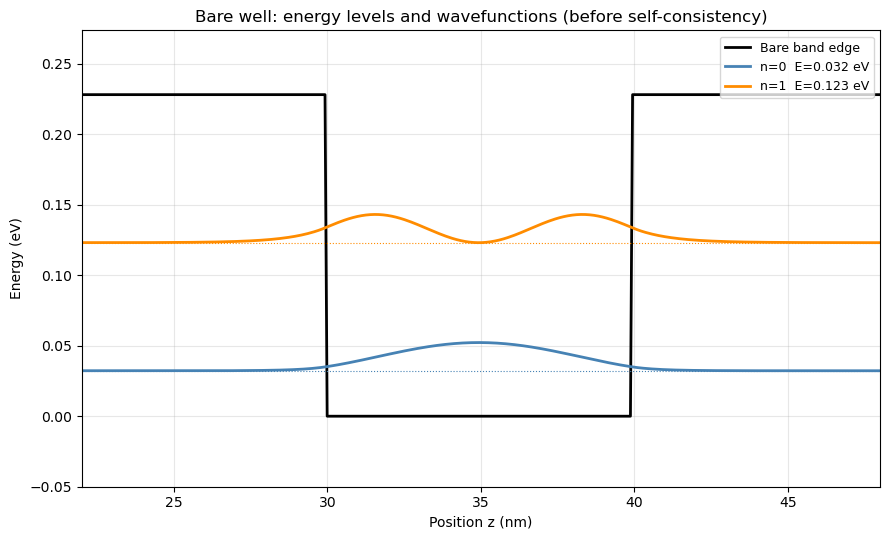

Plot 2 displayed.


In [ ]:
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(z*1e9, Vband/q, color='black', lw=2, label='Bare band edge')

colors = ['steelblue', 'darkorange', 'green']
scale  = 0.02
for n in range(len(E_bare)):
    psi2      = psi_bare[:, n]**2
    psi2_norm = psi2 / psi2.max()
    wf_plot   = scale * psi2_norm + E_bare[n]/q
    ax.plot(z*1e9, wf_plot, color=colors[n], lw=2,
            label=f'n={n}  E={E_bare[n]/q:.3f} eV')
    ax.axhline(E_bare[n]/q, color=colors[n], lw=0.8, ls=':')

ax.set_xlabel('Position z (nm)')
ax.set_ylabel('Energy (eV)')
ax.set_title('Bare well: energy levels and wavefunctions (before self-consistency)')
ax.set_xlim((Lb - 8e-9)*1e9, (Lb + Lw + 8e-9)*1e9)
ax.set_ylim(-0.05, V0/q * 1.20)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [27]:
V_old = Vband.copy()
history = []

for iteration in range(max_iter):
    E, psi = solve_schrodinger(V_old)
    E   = E[:3]
    psi = psi[:, :3]

    # Electron density (assuming all bound subbands occupied equally — limitation)
    n_z = np.sum(psi**2, axis=1)
    n_z = n_z / (np.sum(n_z) * dz)
    rho = -q * n_s * n_z

    phi   = solve_poisson(rho)
    V_new = Vband - q * phi

    V_next = alpha * V_new + (1 - alpha) * V_old
    diff   = np.max(np.abs(V_next - V_old))
    history.append(diff / q * 1000)   # store in meV

    if diff < tolerance:
        print(f"Converged in {iteration+1} iterations.")
        break
    V_old = V_next

V_final = V_next
n_final = n_s * n_z   # final electron density (1/m³)

print(f"\nBound state energies:")
for i, e in enumerate(E):
    print(f"  E{i} = {e/q:.4f} eV")

Converged in 42 iterations.

Bound state energies:
  E0 = 0.0766 eV
  E1 = 0.1662 eV


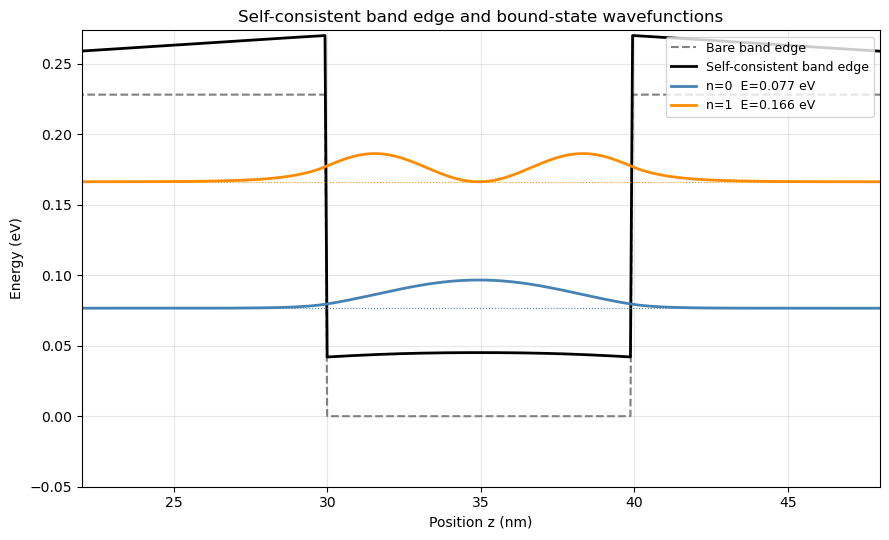

Plot 3 displayed.


In [ ]:
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(z*1e9, Vband/q,   color='gray',  lw=1.5, ls='--', label='Bare band edge')
ax.plot(z*1e9, V_final/q, color='black', lw=2,           label='Self-consistent band edge')

colors = ['steelblue', 'darkorange', 'green']
scale  = 0.02
for n in range(len(E)):
    psi2      = psi[:,n]**2
    psi2_norm = psi2 / psi2.max()
    wf_plot   = scale * psi2_norm + E[n]/q
    ax.plot(z*1e9, wf_plot, color=colors[n], lw=2,
            label=f'n={n}  E={E[n]/q:.3f} eV')
    ax.axhline(E[n]/q, color=colors[n], lw=0.8, ls=':')

ax.set_xlabel('Position z (nm)')
ax.set_ylabel('Energy (eV)')
ax.set_title('Self-consistent band edge and bound-state wavefunctions')
ax.set_xlim((Lb - 8e-9)*1e9, (Lb + Lw + 8e-9)*1e9)
ax.set_ylim(-0.05, V0/q * 1.20)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

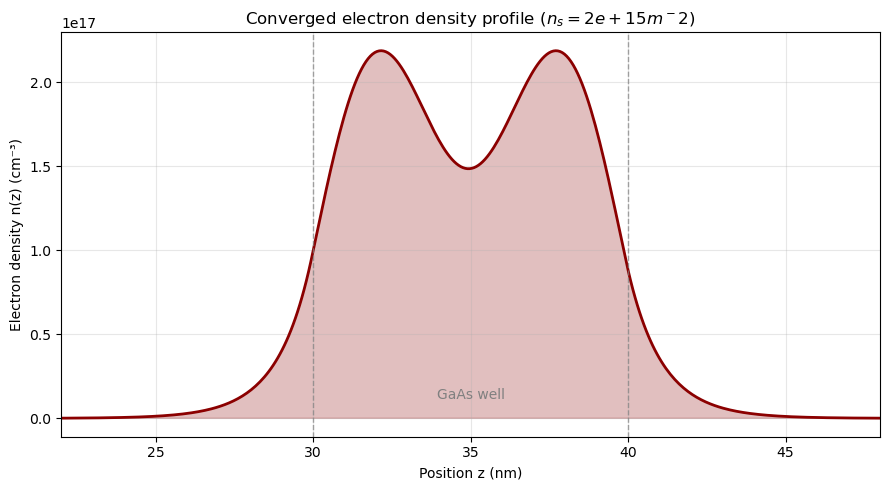

Plot 4 displayed.
  Integrated density: 2.000e+15 m⁻²  (target n_s = 2.000e+15)


In [29]:
fig, ax = plt.subplots(figsize=(9, 5))
# Convert volumetric density (1/m³) to a more readable unit (1/cm³)
ax.plot(z*1e9, n_final/1e6, color='darkred', lw=2)
ax.fill_between(z*1e9, n_final/1e6, alpha=0.25, color='darkred')

# Mark well boundaries
ax.axvline(Lb*1e9,         color='gray', ls='--', lw=1, alpha=0.7)
ax.axvline((Lb + Lw)*1e9,  color='gray', ls='--', lw=1, alpha=0.7)
ax.text(Lb*1e9 + Lw*1e9/2, ax.get_ylim()[1]*0.05,
        'GaAs well', ha='center', fontsize=10, color='gray')

ax.set_xlabel('Position z (nm)')
ax.set_ylabel('Electron density n(z) (cm⁻³)')
ax.set_title(f'Converged electron density profile ($n_s = {n_s:.0e} m^{-2}$)')
ax.set_xlim((Lb - 8e-9)*1e9, (Lb + Lw + 8e-9)*1e9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("Plot 4 displayed.")

# Sanity check: integral of n(z) should equal n_s
integrated = np.sum(n_final) * dz
print(f"  Integrated density: {integrated:.3e} m⁻²  (target n_s = {n_s:.3e})")

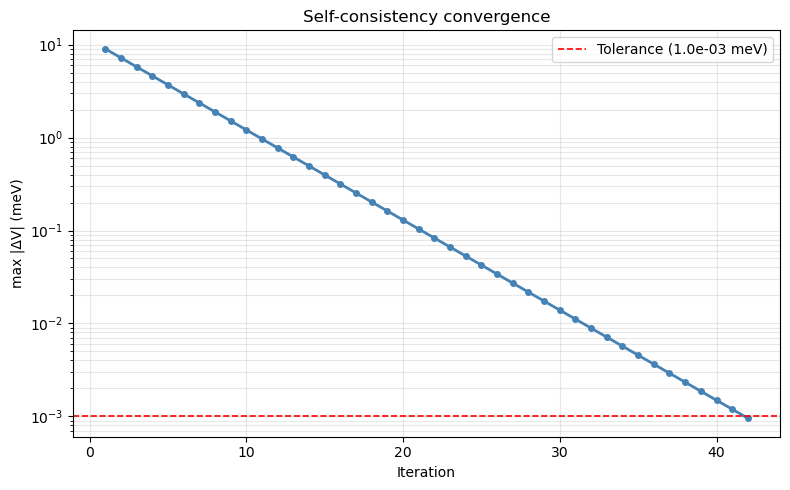

Plot 5 displayed.
  Converged in 42 iterations to 9.54e-04 meV

All plots generated successfully.


In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogy(np.arange(1, len(history)+1), history,
            color='steelblue', lw=2, marker='o', markersize=4)
ax.axhline(tolerance/q*1000, color='red', ls='--', lw=1.2,
           label=f'Tolerance ({tolerance/q*1000:.1e} meV)')
ax.set_xlabel('Iteration')
ax.set_ylabel('max |ΔV| (meV)')
ax.set_title(f'Self-consistency convergence')
ax.legend()
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()
print("Plot 5 displayed.")
print(f"  Converged in {len(history)} iterations to {history[-1]:.2e} meV")